This Project is to implement an AI TTS bot that uses low compute on a local machine. Ideally this program could be utilized on systems without a GPU, as an alternative to paid platforms such as Speechify for students with dyslexia/learning difficulties


# Step 1: Define the Evaluation Goal

This project uses a **DistilBERT sentiment analysis model** (from Hugging Face Transformers) as part of a larger NLP pipeline. The sentiment predictions generated by this model influence the **prosody transformation** applied before speech synthesis.

In other words, the emotional tone of the generated narration depends on the accuracy of the sentiment classifier.

To evaluate the reliability of this component, we test the model using the **Stanford Sentiment Treebank (SST-2)** dataset from the GLUE benchmark.

## Why SST-2?

The SST-2 dataset contains thousands of sentences labeled by humans as either **positive** or **negative** sentiment. Because these labels represent ground truth sentiment, the benchmark gives an objective measurement of model accuracy

By comparing our model's predictions to the labeled sentiment in SST-2, we can measure performance using standard classification metrics. We will mostly look at Accuracy, Precision, Recall, and F1 Score

Evaluating the sentiment model is important because errors in sentiment classification could lead to incorrect **prosody modifications** in the generated narration, affecting the emotional tone of the speech output.

## What is Prosody?

**Prosody** refers to the rhythm, stress, pacing, and emotional tone of spoken language. In human speech, prosody helps convey meaning beyond the literal words being spoken. For example, a sentence spoken with excitement may sound energetic and emphasized, while the same sentence spoken with sadness may sound slower and more subdued. It is effectively the same concept as ending a sentence with a question mark vs an exclamation mark. 


## Reviewing Model Performance

In [3]:
from transformers import pipeline

# Load the same model used in the project
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Device set to use cuda:0


In [4]:
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

dataset = load_dataset("glue", "sst2", split="validation")

preds = []
labels = []

for item in dataset:
    result = sentiment_model(item["sentence"])[0]
    pred = 1 if result["label"] == "POSITIVE" else 0
    preds.append(pred)
    labels.append(item["label"])

accuracy = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9105504587155964
Precision: 0.8978260869565218
Recall: 0.9301801801801802
F1 Score: 0.9137168141592921


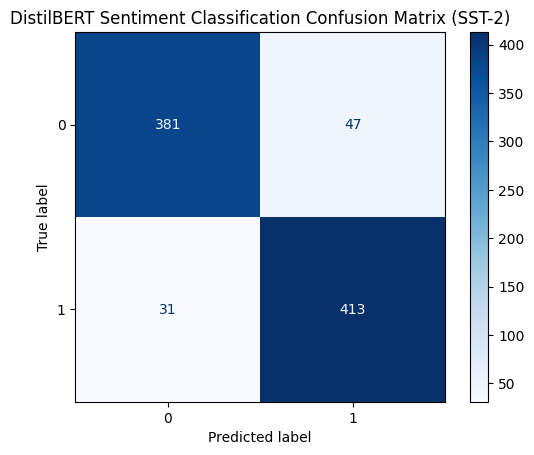

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("DistilBERT Sentiment Classification Confusion Matrix (SST-2)")
plt.show()

## Analysis

These results show that the sentiment model performs well across all evaluation metrics. With scores around 90% for accuracy, precision, recall, and F1, the model is generally good at at identifying whether a sentence expresses positive or negative sentiment. Because the goal of this project is to generate informative text-to-speech narration for content such as news articles or informational text, this level of performance is sufficient for influencing prosody in the generated speech.

However, sentiment classification does not always capture the full emotional tone of language. Transformer models can struggle with sarcasm, irony, or context-dependent meaning, which may result in incorrect sentiment predictions. For applications such as audiobook narration or voice acting, where emotional nuance is more important, these limitations could become more noticeable. 

To improve performance for those types of applications, the model could be fine-tuned on domain-specific text such as books, scripts, or conversational dialogue. Additionally, more advanced sentiment models or multi-class emotion classification systems could be used to provide richer prosody control in the speech synthesis stage. We would also want to look into running a beefier TTS model than Piper, as Piper does not have a ton of space for tonal inflection. FishSpeech would be ideal for that, however it has very expensive compute costs locally, and API keys require a payment which is outside the scope of this project at this time. 